# Capital Asset Pricing Model (CAPM) Time Series Analysis
#### Danny Pan

The provided dataset (credit: Alessandro Rinaldo) contains the daily 3-month Treasury Bill yield and adjusted closing prices for various equities from 11/1/1993 to 4/3/2003. The S&P 500 index is utilized as the proxy representing the overall market return. 

In this project, we will specifically be evaluating Microsoft's (msft) stock performance relative to the market (sp500). Upon cleaning the data, the daily excess return is created for S&P 500 and Microsoft with the formula:

$R_{excess} = R_{asset} - R_{f}$

Where $R_{asset}$ (asset return) is calculated by the percent change in assets and $R_{f}$ (risk-free rate, the expected rate of return on an investment w/ no risk) is represented by the T-bill yield scaled to a daily rate (251 trading days in a year).

The excess returns of both Microsoft and the market over a year period is shown below:

In [37]:
# import data and relevant libraries
from scipy.stats import linregress
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('microsoft_closing_prices.csv')

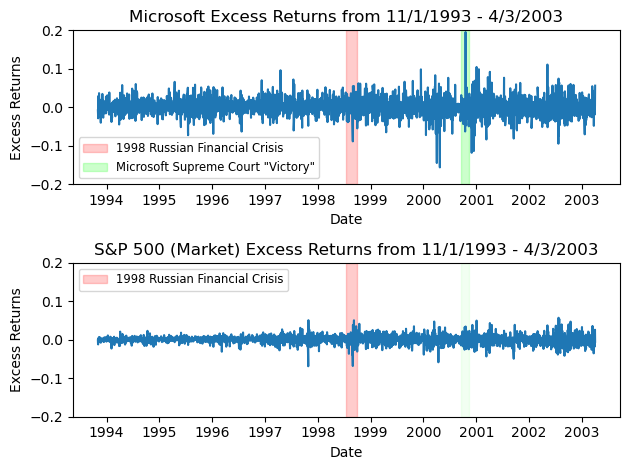

In [38]:
# Cleaning, excess returns feature creation
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y')
df['EX_R_sp500'] = df['Close-sp500'].pct_change() - (df['Close-tbill'] / (100 * 251))
df['EX_R_msft'] = df['Close-msft'].pct_change() - (df['Close-tbill'] / (100 * 251))
df = df.dropna().reset_index(drop=True)

# Visualization
fig, axes = plt.subplots(2, 1)
sns.lineplot(x='Date', y='EX_R_msft', data=df, ax=axes[0])
axes[0].set_title('Microsoft Excess Returns from 11/1/1993 - 4/3/2003')
axes[0].set_ylim(-0.2, 0.2)
axes[0].set_ylabel('Excess Returns')
sns.lineplot(x='Date', y='EX_R_sp500', data=df, ax=axes[1])
axes[1].set_title('S&P 500 (Market) Excess Returns from 11/1/1993 - 4/3/2003')
axes[1].set_ylim(-0.2, 0.2)
axes[1].set_ylabel('Excess Returns')

russia_start, russia_end = pd.to_datetime('1998-07-15'), pd.to_datetime('1998-10-01')
msft_start, msft_end = pd.to_datetime('2000-09-15'), pd.to_datetime('2000-11-15')
axes[0].axvspan(russia_start, russia_end, color='red', alpha=0.2, label='1998 Russian Financial Crisis')
axes[0].axvspan(msft_start, msft_end, color='lime', alpha=0.2, label='Microsoft Supreme Court "Victory"')
axes[1].axvspan(russia_start, russia_end, color='red', alpha=0.2, label='1998 Russian Financial Crisis')
axes[1].axvspan(msft_start, msft_end, color='lime', alpha=0.05)
axes[0].legend(fontsize='small')
axes[1].legend(fontsize='small')

plt.tight_layout()

Naturally, the daily excess returns appear to be more volatile for Microsoft compared to the broader market (the noise is "cancelled out" due to the Law of Large Numbers). Some market behaviors are specific to Microsoft, such as the positive spike (in green) as the result of a minor victory in the Supreme Court in the midst of the antitrust lawsuit against Microsoft. However, patterns of fluctuation in both Microsoft and the S&P 500 are also existent, such as the areas in red, as in the context of Russia devaluing the ruble and defaulting their debt in 1998.

To quantify the relationship between Microsoft’s performance and the broader market, I utilized the **Capital Asset Pricing Model (CAPM)**. This model expresses the expected excess return of an asset as a linear function of the market's excess return:

$$Y_i = \alpha + \beta X_i + \epsilon_i$$

Where:
* $Y_i$: The daily excess return of Microsoft.
* $X_i$: The daily excess return of the S&P 500 (Market Proxy).
* $\beta$ (Beta): The sensitivity of the asset to market movements (Systematic Risk).
* $\alpha$ (Alpha): The intercept, representing risk-adjusted over or under-performance relative to the model.
* $\epsilon_i$: The error term or idiosyncratic factors the market cannot explain.

The following scatterplot confirms a fairly linear relationship between Microsoft's and the market's excess returns:

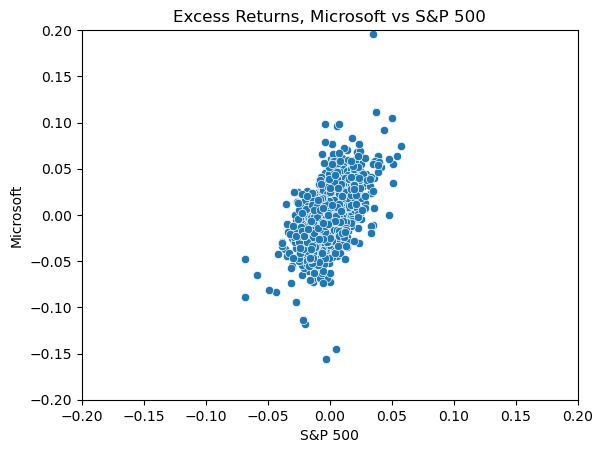

In [39]:
sns.scatterplot(x=df['EX_R_sp500'], y=df['EX_R_msft']).set(
    title='Excess Returns, Microsoft vs S&P 500', 
    xlabel='S&P 500', 
    ylabel='Microsoft', 
    xlim=(-0.2, 0.2), 
    ylim=(-0.2, 0.2)
)
plt.show()

### Rolling Parameter Estimation

While a static CAPM regression provides singular, aggregate parameters for the entire decade, it fails to capture how Microsoft’s risk profile evolved over time. Accordingly, a **rolling linear regression** with a **251-day window** was implemented, with the x-axis representing the center of each 251-day period (representing ~1 trading year). The slope and intercept (beta and alpha) are calculated for each window and plotted below:

* Beta: A horizontal dashed line at $y = 1$ represents the market benchmark.
* Alpha: A horizontal dashed line at $y = 0$ represents the threshold for neutral risk-adjusted performance.

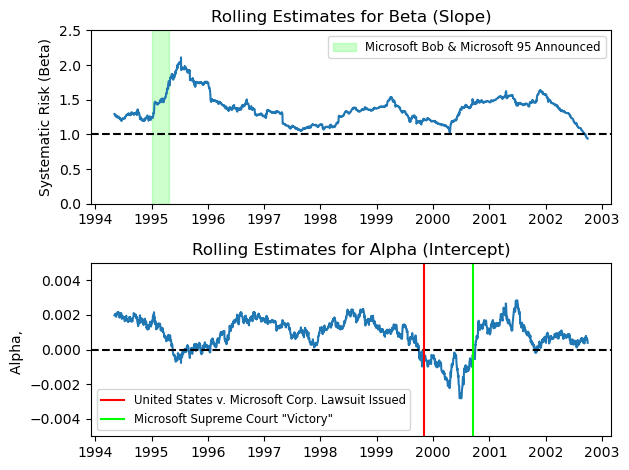

In [40]:
# Rolling linear regression using a 251-day window size
window_size = 251
dates = []
beta = []
alpha = []

for i in range(len(df) - window_size):
    center_idx = i + (window_size // 2)
    dates.append(df['Date'].iloc[center_idx])
    ols_fit = linregress(df['EX_R_sp500'].iloc[i:i+window_size], df['EX_R_msft'].iloc[i:i+window_size])
    beta.append(ols_fit.slope)
    alpha.append(ols_fit.intercept)


fig2, axes2 = plt.subplots(2, 1)
sns.lineplot(x=dates, y=beta, ax=axes2[0])
axes2[0].set_title('Rolling Estimates for Beta (Slope)')
axes2[0].set_ylim(0, 2.5)
axes2[0].set_ylabel('Systematic Risk (Beta)')
axes2[0].axhline(y=1, color='black', linestyle='--')
bob_start = pd.to_datetime('1995-01-05')
bob_end = pd.to_datetime('1995-04-24')
axes2[0].axvspan(bob_start, bob_end, color='lime', alpha=0.2, label='Microsoft Bob & Microsoft 95 Announced')
axes2[0].legend(fontsize='small')

sns.lineplot(x=dates, y=alpha, ax=axes2[1])
axes2[1].set_title('Rolling Estimates for Alpha (Intercept)')
axes2[1].set_ylim(-0.005, 0.005)
axes2[1].set_ylabel('Alpha, ')
axes2[1].axhline(y=0, color='black', linestyle='--')
russia_start, russia_end = pd.to_datetime('2000-02-01'), pd.to_datetime('2000-09-01')
axes2[1].axvline(x=pd.to_datetime('1999-11-05'), color='red', label='United States v. Microsoft Corp. Lawsuit Issued')
axes2[1].axvline(msft_start, color='lime', label='Microsoft Supreme Court "Victory"')
axes2[1].legend(fontsize='small')

plt.tight_layout()

### Rolling Parameter Analysis

Looking at the graph of Beta over time, a value spanning over 1 for the majority of the 10 year period suggests that Microsoft stock prices tend to be an "aggressive" asset, amplifying market movements. The peak occured in 1995 with the release of Windows 95, a revolutionary milestone which made personal computing a lot more accessible to the public. Certain timeframes exhibit a more conformist nature to the broader market, and can be attributed significant events/crisises in the economy or Microsoft Corporation.

While the scale of the rolling alpha values suggest a relatively insignificant effect size on a daily level, the annualized (compounded) effect (>20% on average) suggests that Microsoft consistently outperformed the market benchmarks. However, the effects of the Antitrust lawsuit can definitely be identified within the graph, with security being overpriced upon the start of the lawsuit until the court decision was appealed in Supreme Court.

Due to the nature of the Ordinary Least Squares approach used, the rolling alpha and beta estimators tend to have a negative correlation, however in a practical economical context, this relationship isn't significant. 